In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings("ignore")

In [34]:
CSV_PATH = "/content/all_features_traffic_dataset.csv"
OUT_DIR = "/mnt/data/traffic_rf_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

In [35]:
df = pd.read_csv(CSV_PATH)
print("Loaded dataset with shape:", df.shape)
print("Columns:", df.columns.tolist())

Loaded dataset with shape: (61368, 30)
Columns: ['Timestamp', 'Traffic_Volume', 'Traffic_Speed', 'Traffic_Density', 'Time_of_Day', 'Day_of_Week', 'Weather_Conditions', 'Road_Segment_ID', 'Road_Length', 'Number_of_Lanes', 'Intersection_Info', 'Traffic_Signals', 'Proximity_to_POI', 'Adjacency_Matrix', 'Node_Features', 'Edge_Weights', 'Previous_Time_Steps', 'Incidents_or_Events', 'Population_Density', 'Public_Transport_Data', 'Real_Time_GPS_Data', 'Travel_Time', 'Congestion_Level', 'Delay_Reduction', 'Optimal_Routing_Decisions', 'Emission_Levels', 'Traffic_Incidents', 'Peak_Hour_Prediction', 'Signal_Phase_Duration', 'Queue_Length_Reduction']


In [36]:
# 1) Quick EDA prints
# -----------------------------
print("\n--- Basic info ---")
print(df.info())
print("\n--- Numeric summary (head) ---")
print(df.select_dtypes(include=[np.number]).describe().T.head(10))
print("\n--- Example rows ---")
print(df.head(4))


--- Basic info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Timestamp                  61368 non-null  object 
 1   Traffic_Volume             61368 non-null  int64  
 2   Traffic_Speed              61368 non-null  float64
 3   Traffic_Density            61368 non-null  int64  
 4   Time_of_Day                61368 non-null  int64  
 5   Day_of_Week                61368 non-null  int64  
 6   Weather_Conditions         61368 non-null  object 
 7   Road_Segment_ID            61368 non-null  int64  
 8   Road_Length                61368 non-null  float64
 9   Number_of_Lanes            61368 non-null  int64  
 10  Intersection_Info          61368 non-null  int64  
 11  Traffic_Signals            61368 non-null  int64  
 12  Proximity_to_POI           61368 non-null  float64
 13  Adjacency_Matrix          

In [37]:
# 2) Fuzzy logic features
# -----------------------------
def tri(x, a, b, c):
    """Triangular membership function."""
    x = np.asarray(x, dtype=float)
    return np.maximum(np.minimum((x - a) / (b - a + 1e-9), (c - x) / (c - b + 1e-9)), 0.0)

def minmax01(arr):
    arr = np.asarray(arr, dtype=float)
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx - mn < 1e-9:
        return np.zeros_like(arr)
    return (arr - mn) / (mx - mn)

In [38]:
# Base signals used for fuzzy rules (normalized)
v = minmax01(df["Traffic_Volume"].values) if "Traffic_Volume" in df.columns else np.zeros(len(df))
d = minmax01(df["Traffic_Density"].values) if "Traffic_Density" in df.columns else np.zeros(len(df))
s_raw = minmax01(df["Traffic_Speed"].values) if "Traffic_Speed" in df.columns else np.ones(len(df))*0.5
# invert speed: lower speed -> higher congestion signal
s = 1.0 - s_raw

In [39]:
V_low, V_med, V_high   = tri(v, 0.0, 0.0, 0.5), tri(v, 0.2, 0.5, 0.8), tri(v, 0.5, 1.0, 1.0)
D_low, D_med, D_high   = tri(d, 0.0, 0.0, 0.5), tri(d, 0.2, 0.5, 0.8), tri(d, 0.5, 1.0, 1.0)
S_low, S_med, S_high   = tri(s, 0.0, 0.0, 0.5), tri(s, 0.2, 0.5, 0.8), tri(s, 0.5, 1.0, 1.0)

In [40]:
# simple fuzzy aggregation
high_rules = np.maximum.reduce([V_high, D_high, S_high])
med_rules  = np.maximum.reduce([V_med, D_med, S_med])
low_rules  = np.minimum.reduce([V_low, D_low]) * (1.0 - S_high)

In [41]:
num = 0.2*low_rules + 0.5*med_rules + 0.85*high_rules
den = (low_rules + med_rules + high_rules + 1e-9)
congestion_score_01 = num / den
smart_congestion_index = congestion_score_01 * 100.0
fuzzy_green_time_hint = congestion_score_01  # [0..1]

In [42]:
df["Smart_Congestion_Index"] = smart_congestion_index
df["Fuzzy_Green_Time_Hint"] = fuzzy_green_time_hint
print("\nAdded fuzzy features: Smart_Congestion_Index, Fuzzy_Green_Time_Hint")
print(df[["Smart_Congestion_Index","Fuzzy_Green_Time_Hint"]].head())


Added fuzzy features: Smart_Congestion_Index, Fuzzy_Green_Time_Hint
   Smart_Congestion_Index  Fuzzy_Green_Time_Hint
0               44.477475               0.444775
1               65.316975               0.653170
2               61.026326               0.610263
3               59.963897               0.599639
4               67.896616               0.678966


In [43]:
# 3) Define targets (six outputs)
# -----------------------------
# Mapping from your dataset columns to required outputs
targets_map = {
    "Smart_Traffic_State_Classification": "Congestion_Level",          # categorical
    "Smart_Congestion_Index": "Smart_Congestion_Index",               # numeric (we created)
    "Smart_Signal_Timing": "Signal_Phase_Duration",                   # numeric
    "Smart_Route_Recommendation": "Optimal_Routing_Decisions",        # categorical
    "Smart_Travel_Time_Prediction": "Travel_Time",                    # numeric
    "Smart_Saturation_Time_Forecast": "Queue_Length_Reduction"        # numeric
}


In [44]:

missing = [k for k,v in targets_map.items() if v not in df.columns]
if missing:
    print("WARNING: missing target columns for:", missing)
    # If critical targets missing, they'll throw later; but we continue.

In [45]:
y = pd.DataFrame({
    k: df[v] if v in df.columns else (np.nan if k!="Smart_Congestion_Index" else df["Smart_Congestion_Index"])
    for k, v in targets_map.items()
})


In [46]:
# 4) Build feature set X
#    Drop Timestamp and target columns (to avoid leakage)
# -----------------------------
drop_cols = ["Timestamp"] + list(targets_map.values())
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").copy()

In [47]:
# Ensure no target columns remain in X
for t in targets_map.values():
    if t in X.columns:
        X.drop(columns=[t], inplace=True)

print("\nFinal feature matrix X shape:", X.shape)
print("Target matrix y shape:", y.shape)


Final feature matrix X shape: (61368, 25)
Target matrix y shape: (61368, 6)


In [48]:
#Identify categorical and numeric features
# -----------------------------
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("\nNumeric cols count:", len(num_cols), "; Categorical cols count:", len(cat_cols))



Numeric cols count: 21 ; Categorical cols count: 4


In [49]:
# 6) Preprocessing pipeline
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

In [50]:
# We'll transform X into a dense array for RandomForest
X_transformed = preprocessor.fit_transform(X)
print("\nTransformed feature shape:", X_transformed.shape)


Transformed feature shape: (61368, 38)


In [51]:
# 7) Prepare classification vs regression targets
# -----------------------------
class_targets = ["Smart_Traffic_State_Classification", "Smart_Route_Recommendation"]
reg_targets   = [c for c in y.columns if c not in class_targets]
# If there are NaNs in regression targets, drop those rows
y_reg = y[reg_targets].copy()
y_clf = y[class_targets].copy()

In [52]:
complete_idx = (~y_reg.isna().any(axis=1)) & (~y_clf.isna().any(axis=1))
if not complete_idx.all():
    print(f"Dropping {len(y) - complete_idx.sum()} rows due to missing target values.")
    X_transformed = X_transformed[complete_idx.values]
    y = y[complete_idx.values].reset_index(drop=True)
else:
    y = y.reset_index(drop=True)

In [53]:
X_prepared = pd.DataFrame(X_transformed)

In [54]:
# 8) Train / Test split
# -----------------------------
# Try to stratify by congestion level if possible
stratify_col = None
if "Smart_Traffic_State_Classification" in y.columns and y["Smart_Traffic_State_Classification"].nunique() > 1:
    try:
        stratify_col = y["Smart_Traffic_State_Classification"]
    except Exception:
        stratify_col = None

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.20, random_state=42, stratify=stratify_col
)
print("\nTrain/Test shapes:", X_train.shape, X_test.shape)


Train/Test shapes: (49094, 38) (12274, 38)


In [56]:
# Classifier
clf_base = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
multi_clf = MultiOutputClassifier(clf_base)

In [57]:
# Regressor
reg_base = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
multi_reg = MultiOutputRegressor(reg_base)

In [61]:
# Fit classifier on classification targets
multi_clf.fit(X_train.values, y_train[class_targets].astype(str).values)

MultiOutputClassifier(estimator=RandomForestClassifier(n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42))

In [58]:
# Fit regressor on regression targets
multi_reg.fit(X_train.values, y_train[reg_targets].astype(float).values)

MultiOutputRegressor(estimator=RandomForestRegressor(n_estimators=300,
                                                     n_jobs=-1,
                                                     random_state=42))

In [62]:
# 10) Predict & Evaluate
# -----------------------------
pred_clf = multi_clf.predict(X_test.values)
pred_reg = multi_reg.predict(X_test.values)

In [101]:
y_pred_class = pd.DataFrame(
    multi_clf.predict(X_test.values),
    columns=class_targets
)
y_pred_reg = pd.DataFrame(
    multi_reg.predict(X_test.values),
    columns=reg_targets
)

In [102]:
sample_preds = preds_all.head(6)
print("\n=== 6 Sample predictions ===")
print(sample_preds)


=== 6 Sample predictions ===
  Smart_Traffic_State_Classification Smart_Route_Recommendation  \
0                             Medium                     RouteB   
1                             Medium                     RouteB   
2                             Medium                     RouteA   
3                             Medium                     RouteA   
4                                Low                     RouteA   
5                             Medium                     RouteC   

   Smart_Congestion_Index  Smart_Signal_Timing  Smart_Travel_Time_Prediction  \
0               56.423841           101.546667                      7.091423   
1               63.146555           107.330000                      4.397600   
2               51.291907           106.416667                      6.248126   
3               50.000000           109.520000                      2.574193   
4               60.284120            98.406667                     12.164176   
5               58.9

In [103]:
# 🔹 2. Reports
print("\n===== MODEL PERFORMANCE =====\n")

overall_acc = []
for target in class_targets:
    print(f"--- {target} (Classification) ---")
    print(classification_report(y_test[target].astype(str), y_pred_class[target].astype(str)))
    acc = accuracy_score(y_test[target].astype(str), y_pred_class[target].astype(str))
    overall_acc.append(acc)
    print(f"Accuracy: {acc:.2f}\n")

for target in reg_targets:
    print(f"--- {target} (Regression) ---")
    mae = mean_absolute_error(y_test[target], y_pred_reg[target])
    mse = mean_squared_error(y_test[target], y_pred_reg[target])
    r2 = r2_score(y_test[target], y_pred_reg[target])
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R² Score: {r2:.2f}\n")


===== MODEL PERFORMANCE =====

--- Smart_Traffic_State_Classification (Classification) ---
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      2476
         Low       0.40      0.50      0.45      4886
      Medium       0.40      0.50      0.44      4912

    accuracy                           0.40     12274
   macro avg       0.27      0.33      0.30     12274
weighted avg       0.32      0.40      0.35     12274

Accuracy: 0.40

--- Smart_Route_Recommendation (Classification) ---
              precision    recall  f1-score   support

      RouteA       0.33      0.35      0.34      4065
      RouteB       0.33      0.33      0.33      4077
      RouteC       0.33      0.31      0.32      4132

    accuracy                           0.33     12274
   macro avg       0.33      0.33      0.33     12274
weighted avg       0.33      0.33      0.33     12274

Accuracy: 0.33

--- Smart_Congestion_Index (Regression) ---
MAE: 0.00
MSE: 0.0

In [104]:
print(f"Average Classification Accuracy: {np.mean(overall_acc):.2f}")

Average Classification Accuracy: 0.37



===== CONFUSION MATRICES =====


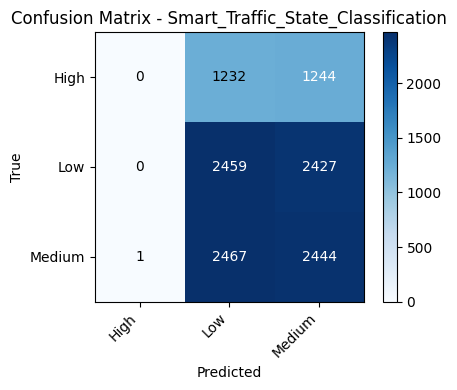

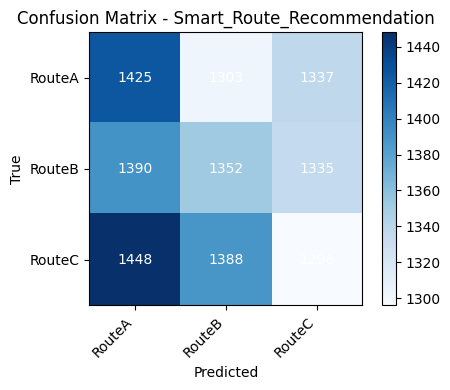

In [107]:
def plot_confusion(y_true, y_pred, title):
    labels = sorted(list(set(y_true.astype(str)) | set(y_pred.astype(str))))
    cm = confusion_matrix(y_true.astype(str), y_pred.astype(str), labels=labels)

    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2. else "black")

    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

print("\n===== CONFUSION MATRICES =====")
for target in class_targets:
    plot_confusion(y_test[target], y_pred_class[target], f"Confusion Matrix - {target}")

In [94]:
sample_preds = preds_all.head(6)
print("\n=== 6 Sample predictions ===")
print(sample_preds)


=== 6 Sample predictions ===
  Smart_Traffic_State_Classification Smart_Route_Recommendation  \
0                             Medium                     RouteB   
1                             Medium                     RouteB   
2                             Medium                     RouteA   
3                             Medium                     RouteA   
4                                Low                     RouteA   
5                             Medium                     RouteC   

   Smart_Congestion_Index  Smart_Signal_Timing  Smart_Travel_Time_Prediction  \
0               56.423841           101.546667                      7.091423   
1               63.146555           107.330000                      4.397600   
2               51.291907           106.416667                      6.248126   
3               50.000000           109.520000                      2.574193   
4               60.284120            98.406667                     12.164176   
5               58.9